## Title: "Individual Planning Report"
## Author: Yingnian Le
## Output: html_document

# (1) Data Description
The dataset consists of two related files: "players.csv" and "sessions.csv", collected from a Minecraft server operated by Frank Wood in lab at UBC.

players.csv:
| Variable     | Type        | Description                                                                 |
|---------------|-------------|------------------------------------------------------------------------------|
| experience    | Categorical | Player experience level (e.g., “Amateur”, “Pro”, “Veteran”)                 |
| subscribe     | Logical     | Whether the player subscribed to the game-related newsletter (TRUE/FALSE)   |
| hashedEmail   | String      | Unique hashed identifier for each player                                    |
| played_hours  | Numeric     | Total number of hours the player spent in the game                          |
| name          | String      | Player’s name                                                               |
| gender        | Categorical | Player gender                                                               |
| Age           | Numeric     | Player age                                                                  |


sessions.csv:
| Varaible             | Type      | Description                           |
|-----------------------|-----------|----------------------------------------|
| hashedEmail           | String    | Links session to a player              |
| start_time            | Datetime  | Session start (DD/MM/YYYY HH:MM)       |
| end_time              | Datetime  | Session end (DD/MM/YYYY HH:MM)         |
| original_start_time   | Numeric   | Original timestamp form                |
| original_end_time     | Numeric   | Original timestamp form                |



Data issues: Possibly missing values in played_hours or Age.
Duplicates could exist if the same session was logged twice.
Time data may need to be converted into consistent time zone. Sampling bias might exist, only players on the research server are recorded.

# (2) Questions
Broad question:
What player characteristics and behaviours are most predictive of subscribing to a game-related newsletter, and how do these features differ between various player types?

Specific question: Can player experience level, playtime, gender, and age predict whether a player subscribes to the newsletter?

Response variable: subcribe (TRUE/FALSE)
Explanatory variables: experience, played-hours, Age, gender

## (3) Exploratory Data Analysis and Visualization

In [1]:
#Load packages
library(tidyverse)
library(tidymodels)
library(lubridate)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
── Attaching packages ────────────────────────────────────── tidymodels 1.1.1 ──

✔ broom        1.0.6     ✔ rsample      1.2.1
✔ dials        1.3.0     ✔ tune         1.1.2
✔ infer        1.0.7     ✔ workflows    1.1.4
✔ modeldata    1.4.0     ✔ workflowsets 1.0.1
✔ parsnip      1.2.1     ✔ yardstick    1.3.1
✔ recipes      1.1.0     

── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ scales::discard() masks purrr::discard()
✖ dplyr::filt

In [2]:
# Load datasets
players <- read_csv("data/players.csv")
sessions <- read_csv("data/sessions.csv")

glimpse(players)
glimpse(sessions)

Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1535 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): hashedEmail, start_time, end_time
dbl (2): original_start_time, original_end_time

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 196
Columns: 7
$ experience   <chr> "Pro", "Veteran", "Veteran", "Amateur", "Regular", "Amate…
$ subscribe    <lgl> TRUE, TRUE, FALSE, TRUE, TRUE, TRUE, TRUE, FALSE, TRUE, T…
$ hashedEmail  <chr> "f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8…
$ played_hours <dbl> 30.3, 3.8, 0.0, 0.7, 0.1, 0.0, 0.0, 0.0, 0.1, 0.0, 1.6, 0…
$ name         <chr> "Morgan", "Christian", "Blake", "Flora", "Kylie", "Adrian…
$ gender       <chr> "Male", "Male", "Male", "Female", "Male", "Female", "Fema…
$ Age          <dbl> 9, 17, 17, 21, 21, 17, 19, 21, 47, 22, 23, 17, 25, 22, 17…
Rows: 1,535
Columns: 5
$ hashedEmail         <chr> "bfce39c89d6549f2bb94d8064d3ce69dc3d7e72b38f431d8a…
$ start_time          <chr> "30/06/2024 18:12", "17/06/2024 23:33", "25/07/202…
$ end_time            <chr> "30/06/2024 18:24", "17/06/2024 23:46", "25/07/202…
$ original_start_time <dbl> 1.71977e+12, 1.71867e+12, 1.72193e+12, 1.72188e+12…
$ original_end_time   <dbl> 1.71977e+12, 1.71867e+12, 1.72193e+12, 1.72188e+

In [3]:
players |>
summarize(mean_age = round(mean(Age, na.rm = TRUE), 2),
          mean_played = round(mean(played_hours, na.rm = TRUE), 2))

mean_age,mean_played
<dbl>,<dbl>
21.14,5.85


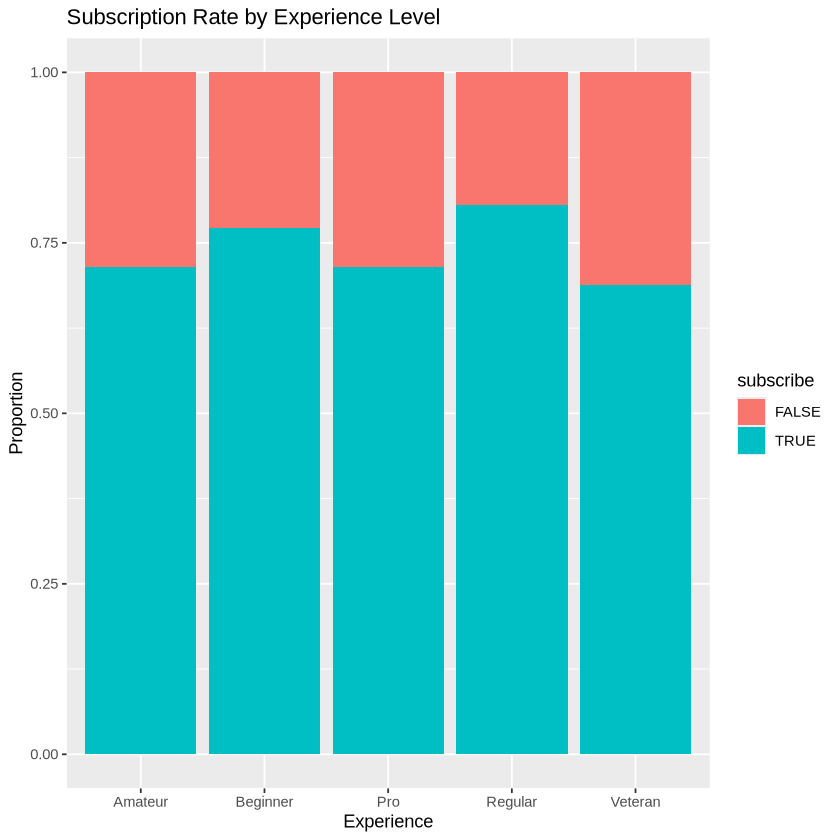

In [4]:
# Plot 1: Subscription proportion by experience
ggplot(players, aes(x = experience, fill = subscribe)) +
  geom_bar(position = "fill") +
  labs(title = "Subscription Rate by Experience Level", y = "Proportion", x = "Experience")

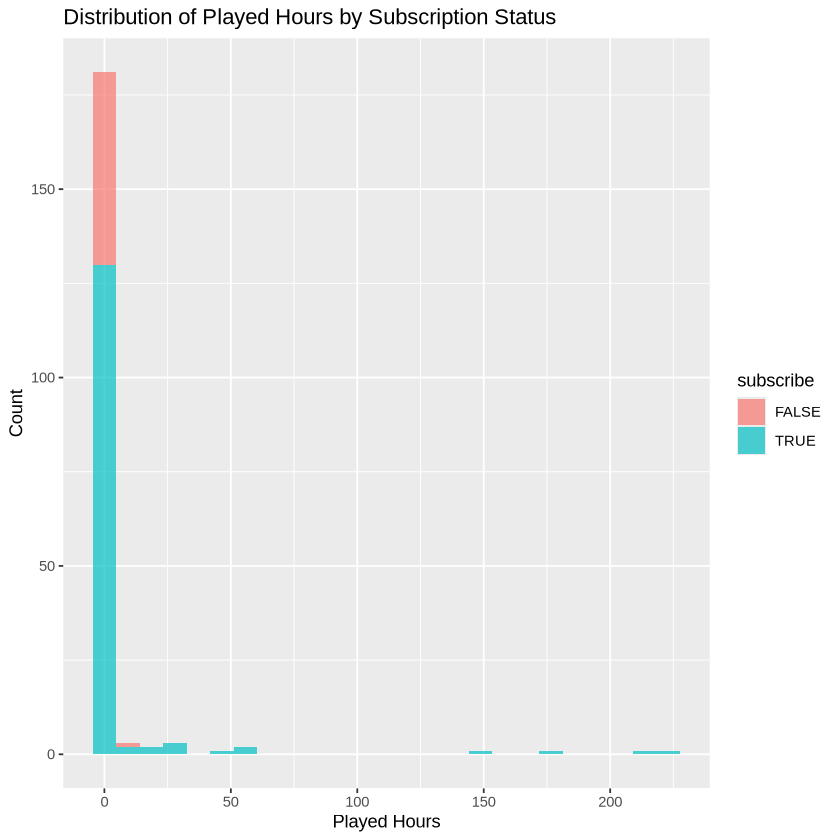

In [5]:
# Plot 2: Played hours vs. Subscription
ggplot(players, aes(x = played_hours, fill = subscribe)) +
  geom_histogram(bins = 25, alpha = 0.7) +
  labs(title = "Distribution of Played Hours by Subscription Status", x = "Played Hours", y = "Count")

Warning message:
“Removed 2 rows containing non-finite outside the scale range
(`stat_density()`).”


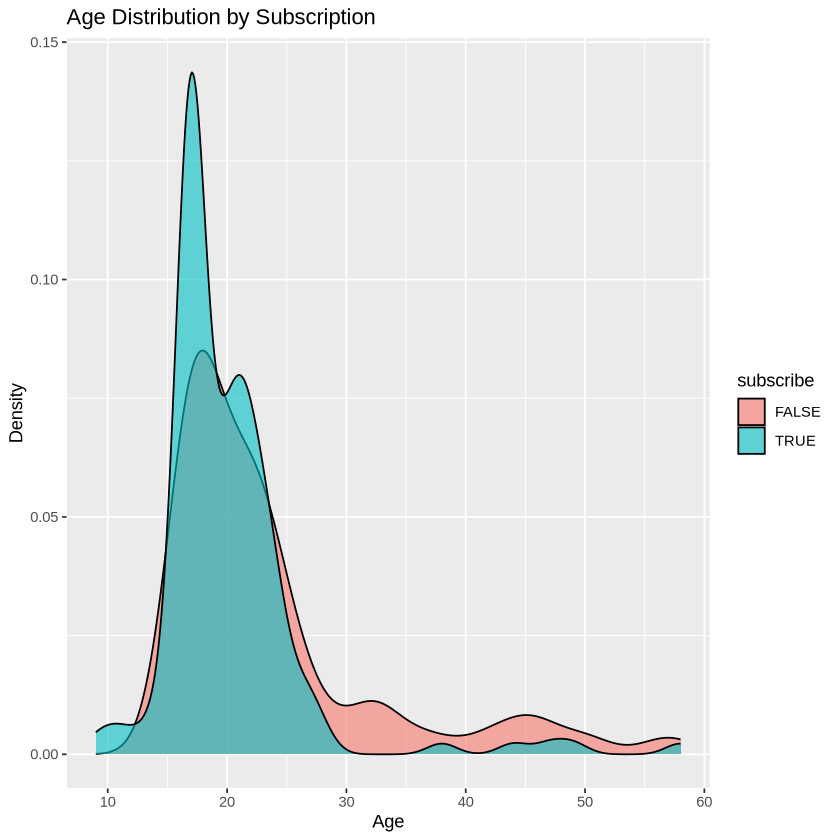

In [6]:
# Plot 3: Age distribution
ggplot(players, aes(x = Age, fill = subscribe)) +
  geom_density(alpha = 0.6) +
  labs(title = "Age Distribution by Subscription", x = "Age", y = "Density")

Experienced players and those with more total hours are more likely to subscribe.
Age appears weakly related to subscription, while gender effects seem minimal.

## (4) Methods and Plan
Following Data Science: A First Introduction, I will use K-Nearest Neighbors (KNN) classification.
I choose this method because KNN is a non-parametric classification algorithm introduced in the course textbook. It predicts class membership (subscribe TRUE/FALSE) by comparing players to their most similar peers.

Assumptions:
Nearby players in feature space will behave similarly.
Variables must be standardized to fair distance measurement.
Limitations:
Sensitive to irrelevant predictors and scaling.
May perform poorly on imbalanced data or with few observations.

Plan:
Split data to 70% for training and 30% for testing.
Use 5-fold cross-validation on training data to choose optimal k.
Evaluate using accuracy and confusion matrix (per textbook method).
Preprocess with step_normalize() and step_dummy() in a recipe().

In [7]:
set.seed(123)
players_split <- initial_split(players, prop = 0.7, strata = subscribe)
players_train <- training(players_split)
players_test <- testing(players_split)

In [8]:
player_recipe <- recipe(subscribe ~ experience + played_hours + Age + gender, data = players_train) |>
step_scale(all_predictors()) |>
step_center(all_predictors())


In [9]:
knn_spec <- nearest_neighbor(weight_func = "rectangular", neighbors = tune()) |>
  set_mode("classification") |>
  set_engine("kknn")

In [10]:
knn_workflow <- workflow() |>
  add_recipe(player_recipe) |>
  add_model(knn_spec)